# 02 — Dataset Viewer

**Goal:** Visually audit image/mask pairs before training.  
Confirm that the masks line up with the rover images and that class colours are what you expect.

---

## Why do we visualise before training?

This is a **data audit** — one of the most important steps in any ML project.

Things to look for:
- Do the mask boundaries follow visible terrain edges in the photo?
- Are the class colours consistent across samples?
- Do any masks look completely black (all zeros) or corrupted?
- Are there many 255-labelled (ignored) pixels that reduce usable training data?

> **Prerequisite:** Run `01_dataset_inspection.ipynb` first to build and validate `pairs`.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from src.data_paths import RAW_DATA_DIR
from src.dataset import find_image_files, find_mask_files, build_pairs_by_stem
from src.visualize import (
    show_sample,
    show_image_mask_overlay,
    print_mask_distribution,
    CLASS_NAMES,
    CLASS_NAME_SCHEMES,
    detect_label_scheme,
)


## Step 1 — Build Pairs

If you have already confirmed correct pairing in notebook 01, re-run it here.  
Alternatively, you can define pairs manually for a quick test.

In [2]:
DATA_ROOT = RAW_DATA_DIR  # adjust if needed

image_files = find_image_files(DATA_ROOT)
mask_files  = find_mask_files(DATA_ROOT)
pairs       = build_pairs_by_stem(image_files, mask_files)

print(f"Total pairs available: {len(pairs)}")

# ------------------------------------------------------------------
# Manual override: uncomment and edit to define a few pairs by hand
# ------------------------------------------------------------------
# pairs = [
#     (DATA_ROOT / "images" / "some_image.jpg", DATA_ROOT / "masks" / "some_image.png"),
# ]

Total pairs available: 46460


## Step 2 — View Individual Samples

`show_sample` loads the files, prints diagnostics, and shows three panels:  
original image / class mask / overlay.

In [ ]:
# Visualise the first sample
if pairs:
    show_sample(*pairs[0])
else:
    print("No pairs found. Check DATA_ROOT and run 01_dataset_inspection.ipynb first.")

## Step 3 — View Multiple Samples

This project predominantly targets the **NAV** scheme (soil/bedrock/sand/big_rock
traversability), so we restrict to NAV-labelled pairs here and draw a *random*
sample rather than just the first few files (which tend to come from the same
rover sequence and bias the audit). Adjust `NUM_SAMPLES` and `SEED` below.


NAV-scheme pairs available: 37958 / 46460 total

Sample 1/5
Image  : 1n320568561effabjkp1981l0m1.JPG  shape=(1024, 1024, 3)  dtype=uint8
Mask   : 1n320568561effabjkp1981l0m1_merged10.png  shape=(1024, 1024)  dtype=int64
Label scheme: NAV
Unique class IDs in mask: [1, 2, 255]

Mask class distribution (total 1048576 pixels):
  class   1 (   bedrock):    45390 px  (  4.3%)
  class   2 (      sand):   428755 px  ( 40.9%)
  class 255 (    ignore):   574431 px  ( 54.8%)


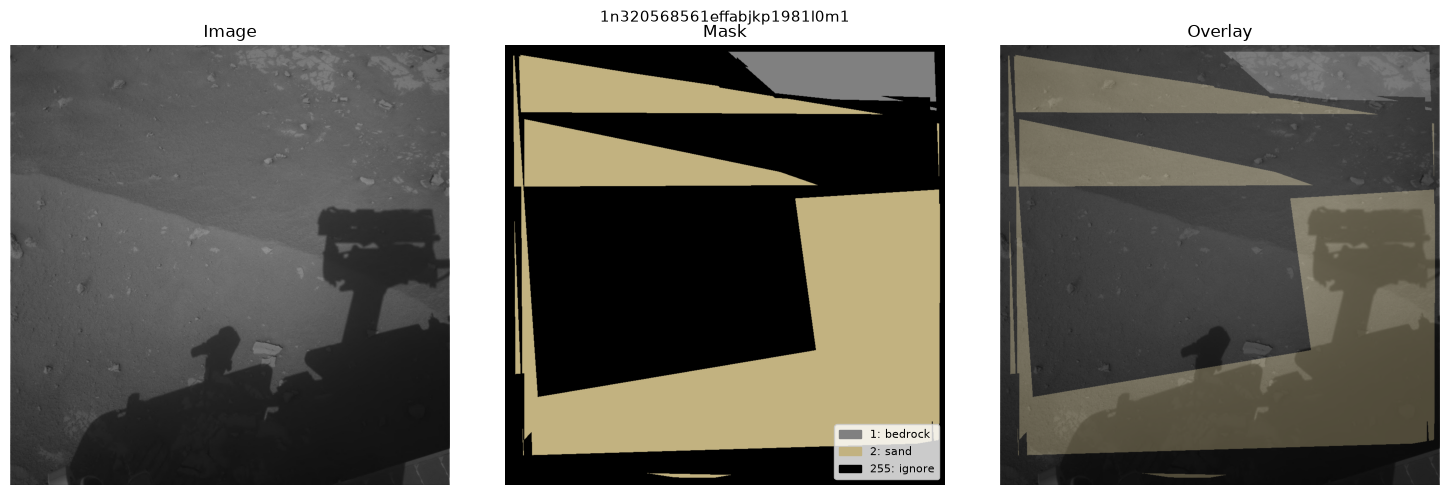


Sample 2/5
Image  : NLF_0147_0680002480_895ECM_N0051812NCAM00500_01_295J.jpeg  shape=(240, 1280, 3)  dtype=uint8
Mask   : NLF_0147_0680002480_895ECM_N0051812NCAM00500_01_295J_merged10.png  shape=(240, 1280)  dtype=int64
Label scheme: NAV
Unique class IDs in mask: [0, 1, 2, 3, 255]

Mask class distribution (total 307200 pixels):
  class   0 (      soil):     1144 px  (  0.4%)
  class   1 (   bedrock):    88965 px  ( 29.0%)
  class   2 (      sand):    63986 px  ( 20.8%)
  class   3 (  big_rock):        3 px  (  0.0%)
  class 255 (    ignore):   153102 px  ( 49.8%)


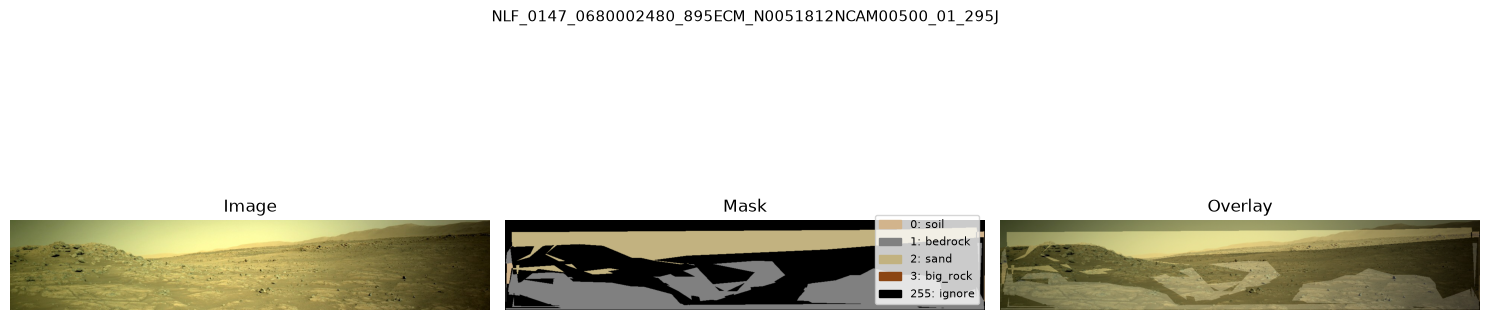


Sample 3/5
Image  : 1669ML0086550040700636E01_XXXX.JPG  shape=(1184, 1328, 3)  dtype=uint8
Mask   : 1669ML0086550040700636E01_XXXX_15033_merged.png  shape=(1184, 1328)  dtype=int64
Label scheme: NAV
Unique class IDs in mask: [0, 2, 4]

Mask class distribution (total 1572352 pixels):
  class   0 (      soil):   602413 px  ( 38.3%)
  class   2 (      sand):   760306 px  ( 48.4%)
  class   4 (   unknown):   209633 px  ( 13.3%)


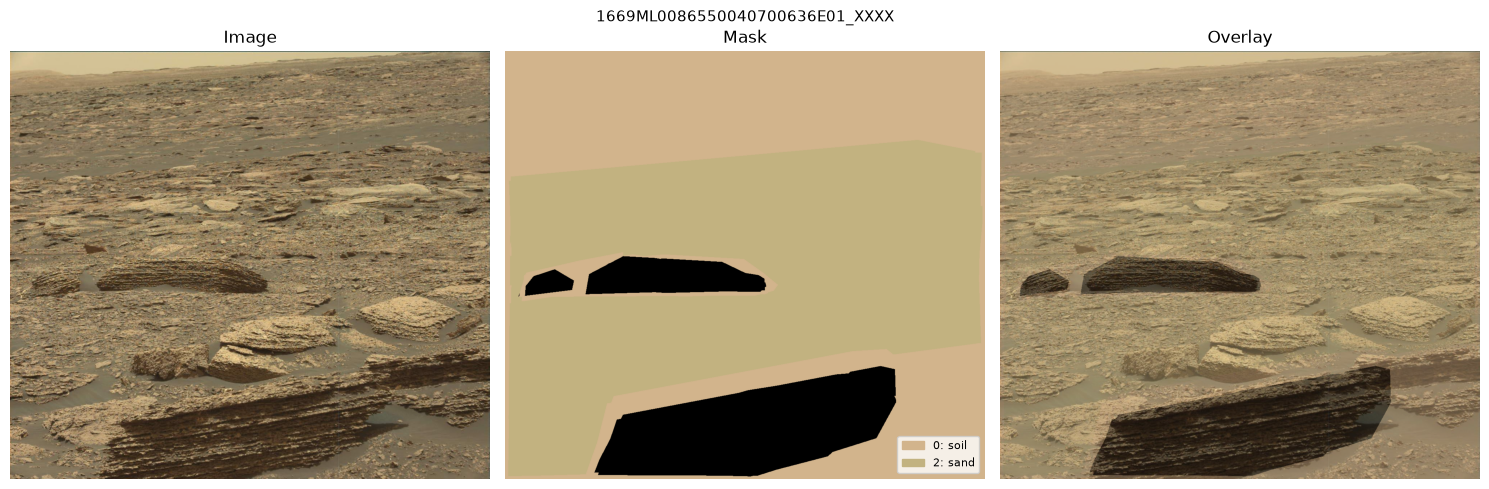


Sample 4/5
Image  : 1435ML0070940000602559E01_XXXX.JPG  shape=(1200, 1344, 3)  dtype=uint8
Mask   : 1435ML0070940000602559E01_XXXX_15033_merged.png  shape=(1200, 1344)  dtype=int64
Label scheme: NAV
Unique class IDs in mask: [0, 1, 2, 4]

Mask class distribution (total 1612800 pixels):
  class   0 (      soil):   218217 px  ( 13.5%)
  class   1 (   bedrock):   308907 px  ( 19.2%)
  class   2 (      sand):   948130 px  ( 58.8%)
  class   4 (   unknown):   137546 px  (  8.5%)


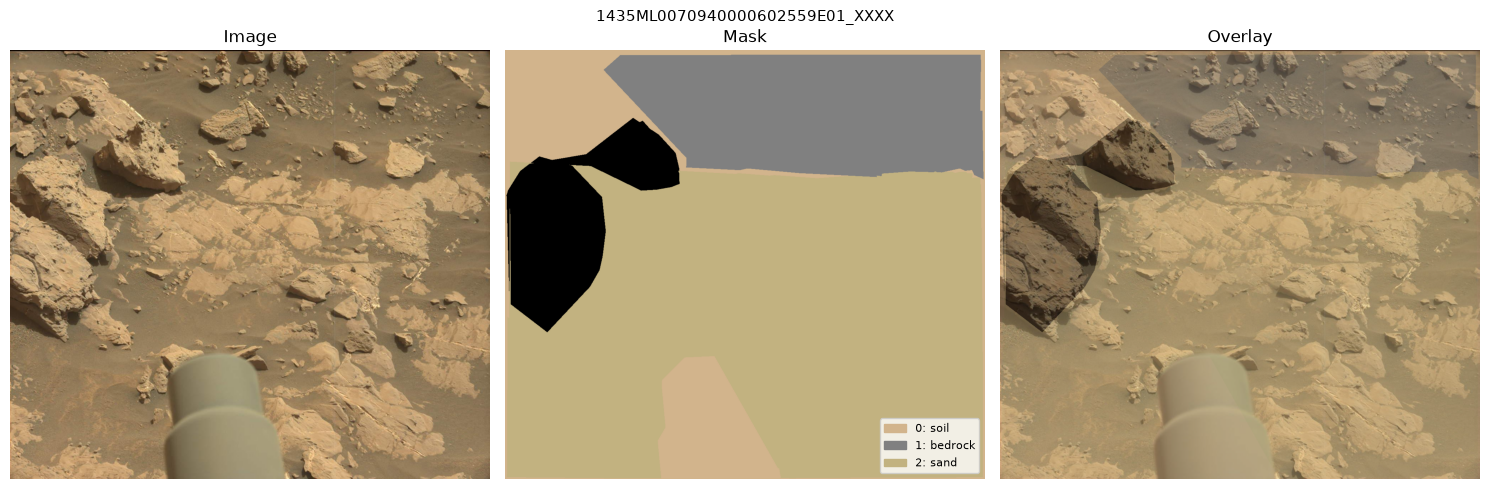


Sample 5/5
Image  : 1329ML0063760030406166E01_XXXX.JPG  shape=(432, 656, 3)  dtype=uint8
Mask   : 1329ML0063760030406166E01_XXXX_15033_merged.png  shape=(432, 656)  dtype=int64
Label scheme: NAV
Unique class IDs in mask: [0, 1, 2]

Mask class distribution (total 283392 pixels):
  class   0 (      soil):     7698 px  (  2.7%)
  class   1 (   bedrock):    22500 px  (  7.9%)
  class   2 (      sand):   253194 px  ( 89.3%)


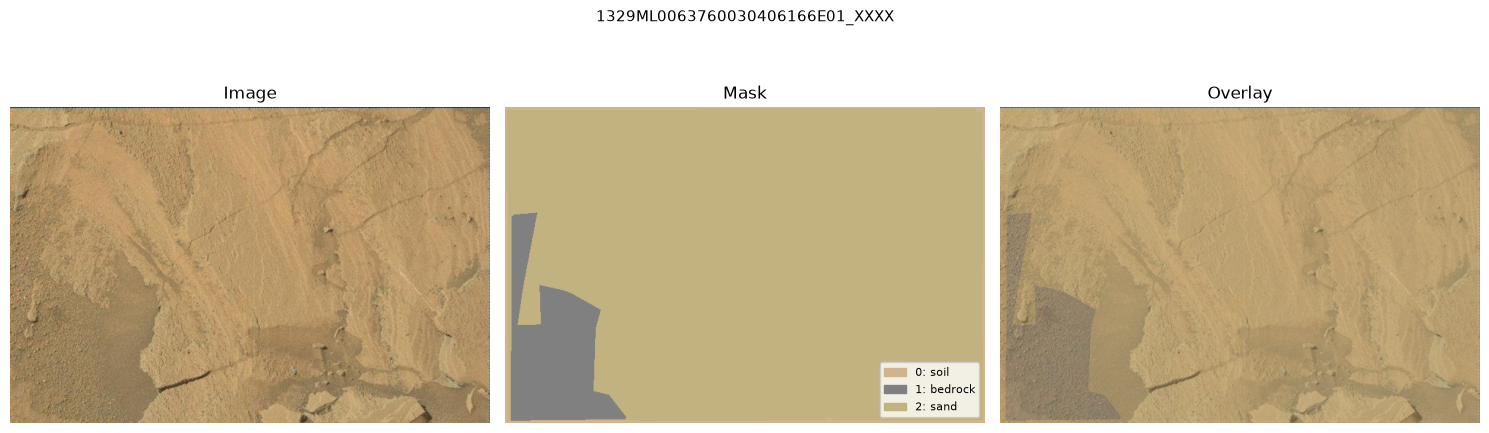

In [3]:
import random

# Restrict to the NAV scheme (soil/bedrock/sand/big_rock traversability),
# since that's the predominant scheme and the primary target for this project.
# M2020_GEO (Perseverance geology, beta) pairs are excluded here.
nav_pairs = [(img, msk) for img, msk in pairs if detect_label_scheme(msk) == "NAV"]
print(f"NAV-scheme pairs available: {len(nav_pairs)} / {len(pairs)} total")

# Adjust NUM_SAMPLES to see more or fewer; SEED keeps the sample reproducible
# across re-runs (set to None for a different random sample each time).
NUM_SAMPLES = 5  # start small; increase to 25 after verifying everything looks correct
SEED = 42

rng = random.Random(SEED)
sample_pairs = rng.sample(nav_pairs, min(NUM_SAMPLES, len(nav_pairs)))

for i, (img_path, msk_path) in enumerate(sample_pairs):
    print(f"\n{'='*60}")
    print(f"Sample {i+1}/{len(sample_pairs)}")
    show_sample(img_path, msk_path)


## Step 4 — Class Distribution Across All Viewed Samples

Understanding class imbalance is important for choosing a loss function and  
interpreting metric results.

In [4]:
import numpy as np
from PIL import Image
from collections import defaultdict

# Reuse the same random NAV-scheme sample drawn in Step 3 so the distribution
# below matches exactly what you just visually inspected.
class_totals = defaultdict(int)

for img_path, msk_path in sample_pairs:
    mask = np.array(Image.open(msk_path))
    scheme = detect_label_scheme(msk_path)
    for cid in np.unique(mask):
        class_totals[(scheme, int(cid))] += int((mask == cid).sum())

grand_total = sum(class_totals.values())
print(f"Aggregate class distribution across {len(sample_pairs)} samples ({grand_total} total pixels):")
print(f"\n{'Scheme':>10}  {'Class':>5}  {'Name':>24}  {'Pixels':>10}  {'%':>6}")
print("-" * 65)
for scheme, cid in sorted(class_totals):
    name = CLASS_NAME_SCHEMES[scheme].get(cid, "unknown")
    count = class_totals[(scheme, cid)]
    pct = 100.0 * count / grand_total
    print(f"{scheme:>10}  {cid:>5}  {name:>24}  {count:>10}  {pct:>5.1f}%")


Aggregate class distribution across 5 samples (4824320 total pixels):

    Scheme  Class                      Name      Pixels       %
-----------------------------------------------------------------
       NAV      0                      soil      829472   17.2%
       NAV      1                   bedrock      465762    9.7%
       NAV      2                      sand     2454371   50.9%
       NAV      3                  big_rock           3    0.0%
       NAV      4                   unknown      347179    7.2%
       NAV    255                    ignore      727533   15.1%


## Next Steps

Once you are satisfied that:
- Mask boundaries align with visible terrain in the images.
- Class IDs are correct and the distribution is understood.
- There are no obviously corrupted samples.

Open `03_baseline_training.ipynb` to train your first model.